# 06 — Hybrid Recommendation via Weighted Reciprocal Rank Fusion

**Problem.** Notebooks 03–05 produced five individual models whose *measured* strengths differ by an order of magnitude and whose failure modes differ in kind: item-item and SASRec tie at the top but cannot see cold items; the content model trails slightly on warm data but is the only leg with cold reach; ALS and popularity are weak alone. A production system must serve one list. The question of this notebook is strictly empirical: **does fusing the legs beat the best single leg, and by how much?**

**Objective.** Fuse all legs with weighted Reciprocal Rank Fusion, where the weights are *derived from measured validation strength* through a single temperature parameter β — tuned on a validation split carved from training data, never on test. Evaluate the frozen configuration once on the untouched test protocol of Notebooks 03–05, including the cold-item subset, and promote the hybrid into serving only if it clears the pre-committed threshold (+5% NDCG@10 over the best single model).

## 1. Introduction

Hybridization strategies range from switching (pick one model per context) to feature combination to score blending (Burke, 2002). Score blending is fragile across heterogeneous models — a cosine similarity, an ALS dot product, and a softmax logit live on incomparable scales. Rank fusion sidesteps calibration entirely by discarding scores and keeping only each model's *ordering*. This notebook's design has one further principle: **no hand-picked weights.** Every fusion parameter is either a literature constant (k = 60) or selected on validation data — so when the jury asks "why is item-item weighted more than ALS?", the answer is a measurement, not a preference.

## 2–3. Theory and mathematical formulation

**Weighted RRF** (Cormack, Clarke & Buettcher, 2009). Given ranked lists from legs $m = 1..M$ with weights $w_m$:
$$\mathrm{RRF}(i) = \sum_{m : i \in L_m} \frac{w_m}{k + \mathrm{rank}_m(i)}, \qquad k = 60$$
Rank-based fusion is scale-invariant, and its *consensus property* is the mechanism that lets a hybrid beat its best leg: an item ranked moderately by two legs accumulates more score than an item ranked well by one — fusion rewards agreement. **Deep lists in, truncate after**: legs contribute their top-$D$ ($D = 50$); fusing already-truncated lists degenerates to concatenation.

**Strength-derived weights with temperature.** Let $s_m$ be leg $m$'s validation NDCG@10. Weights are
$$w_m(\beta) = \frac{s_m^{\beta}}{\sum_{m'} s_{m'}^{\beta}}$$
One scalar spans the whole design space: $\beta = 0$ gives equal weights (pure RRF democracy); $\beta \to \infty$ gives winner-takes-all (best single leg); intermediate $\beta$ trusts stronger legs proportionally more. $\beta$ is selected by grid search **on validation NDCG only** — test data is opened exactly once, after every parameter is frozen.

**Validation protocol.** Within each user's *training* history, the chronologically last item becomes the validation target and the remainder the tuning-training set (users with only 2 training interactions contribute no validation row). This mirrors the outer leave-last-out split one level down, so tuning optimizes exactly the quantity the test measures — without touching it.

## 4. Setup — data, outer split, artifacts

Same deterministic outer split as Notebooks 03–05. The full-train legs are loaded from the exported artifacts of the previous notebooks — the fusion evaluates the *same* objects the backend serves.

In [1]:
import json
import pickle
import time
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from recsys.config import get_settings
from recsys.models.hybrid import (
    HybridRecommender, evaluate_rankings, select_beta,
    strength_weights, weighted_rrf,
)

settings = get_settings()
processed_dir = settings.processed_data_dir
RESULTS_DIR = Path("results"); RESULTS_DIR.mkdir(exist_ok=True)
FIGURES_DIR = Path("figures"); FIGURES_DIR.mkdir(exist_ok=True)
ARTIFACTS_DIR = Path("artifacts") / "hybrid"; ARTIFACTS_DIR.mkdir(parents=True, exist_ok=True)

interactions = pd.read_parquet(processed_dir / "interactions.parquet")


def leave_last_out(frame: pd.DataFrame) -> tuple[pd.DataFrame, pd.DataFrame]:
    ordered = frame.sort_values(["user_id", "timestamp"])
    test_index = ordered.groupby("user_id").tail(1).index
    return ordered.drop(test_index).copy(), ordered.loc[test_index].copy()


train_interactions, test_interactions = leave_last_out(interactions)
train_items = set(train_interactions["item_id"])
raw_test = test_interactions.copy()
test_interactions = test_interactions[
    test_interactions["item_id"].isin(train_items)
    & test_interactions["user_id"].isin(set(train_interactions["user_id"]))
]

def load(p):
    with open(p, "rb") as f:
        return pickle.load(f)

popularity_model = load("artifacts/baselines/popularity_model.pkl")
item_item_model = load("artifacts/baselines/item_item_model.pkl")
als_model = load("artifacts/baselines/als_model.pkl")
content_model = load("artifacts/content/content_model.pkl")
sasrec_model = load("artifacts/sasrec/sasrec_model.pkl")
print("all five legs loaded from artifacts")

hist_ordered = (train_interactions.sort_values(["user_id", "timestamp"])
                .groupby("user_id")["item_id"].agg(list).to_dict())
user_seen = {u: set(h) for u, h in hist_ordered.items()}

DEPTH, K, RNG_SEED = 50, 10, 42


def leg_rankings(user_id: str, history: list[str], seen: set[str],
                 models: dict, depth: int = DEPTH) -> dict[str, list[str]]:
    return {
        "item_item": models["item_item"].recommend(seed_items=history, limit=depth),
        "sasrec": models["sasrec"].recommend(seed_items=history,
                                             seen_items=seen, limit=depth),
        "content": models["content"].recommend(seed_items=history,
                                               seen_items=seen, limit=depth),
        "als": models["als"].recommend(user_id=user_id,
                                       seen_items=seen, limit=depth),
        "popularity": models["popularity"].recommend(seen_items=seen, limit=depth),
    }

full_models = {"popularity": popularity_model, "item_item": item_item_model,
               "als": als_model, "content": content_model, "sasrec": sasrec_model}

all five legs loaded from artifacts


## 5. Complementarity analysis — is there anything to fuse?

Fusion only helps if the legs disagree *productively*: different top-10 lists (low pairwise overlap) yet overlapping hit sets would mean redundancy; disjoint hit sets mean each leg retrieves users the others miss — the raw material of a consensus gain. Both are measured below on the test sample (a descriptive analysis; no tuning happens here).

In [2]:
test_sample = test_interactions.sample(
    n=min(5000, len(test_interactions)), random_state=RNG_SEED)

t0 = time.time()
test_leg_rankings = {}
for row in test_sample.itertuples():
    u = row.user_id
    test_leg_rankings[u] = leg_rankings(u, hist_ordered.get(u, []),
                                        user_seen.get(u, set()), full_models)
print(f"precomputed deep rankings for {len(test_leg_rankings):,} users "
      f"in {time.time()-t0:,.0f}s")

truth_test = dict(zip(test_sample.user_id, test_sample.item_id))
legs = ["item_item", "sasrec", "content", "als", "popularity"]

# pairwise top-10 Jaccard overlap
jac = pd.DataFrame(index=legs, columns=legs, dtype=float)
for a in legs:
    for b in legs:
        vals = []
        for u, r in test_leg_rankings.items():
            sa, sb = set(r[a][:10]), set(r[b][:10])
            if sa or sb:
                vals.append(len(sa & sb) / len(sa | sb))
        jac.loc[a, b] = float(np.mean(vals))

# hit-set overlap among the three strong legs
hitset = {leg: {u for u, r in test_leg_rankings.items()
                if truth_test[u] in r[leg][:10]} for leg in legs}
strong = ["item_item", "sasrec", "content"]
union_strong = set().union(*[hitset[s] for s in strong])
print("\nhits per leg:", {l: len(hitset[l]) for l in legs})
print("union of hits (item_item | sasrec | content):", len(union_strong),
      f"-> ceiling HR@10 if fusion were perfect: {len(union_strong)/len(test_sample):.4f}")
jac.round(3)

precomputed deep rankings for 3,594 users in 33s

hits per leg: {'item_item': 277, 'sasrec': 275, 'content': 238, 'als': 52, 'popularity': 41}
union of hits (item_item | sasrec | content): 486 -> ceiling HR@10 if fusion were perfect: 0.1352


,item_item,sasrec,content,als,popularity
item_item,1.000,0.073,0.025,0.063,0.026
sasrec,0.073,1.000,0.018,0.013,0.011
content,0.025,0.018,1.000,0.007,0.001
als,0.063,0.013,0.007,1.000,0.056
popularity,0.026,0.011,0.001,0.056,1.000


The **union of hit sets** printed above is the theoretical ceiling of any rank fusion at this depth: fusion can surface an item only if *some* leg ranked it. The gap between the best single leg's hits and the union is the prize fusion plays for; the Jaccard matrix shows how differently the legs think.

## 6. Weight tuning on validation (β selection)

Legs are retrained on the tuning-training set (training data minus each user's last item) so the validation targets are unseen by every leg — the content model needs no retraining (its embeddings are interaction-free; only its input seeds change), SASRec is retrained (~8 min CPU). Per-leg validation NDCG becomes the strength vector; β is chosen by grid search on validation NDCG of the fused list.

tuning split: sub-train 17,535 | validation targets 3,516


C:\Users\amira04\Desktop\RS_vfinal\src\recsys\models\sasrec.py:41: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True
  self.encoder = nn.TransformerEncoder(layer, num_layers=n_blocks)


tuning legs ready in 264s
validation rankings precomputed in 30s
validation NDCG@10 per leg: {'item_item': np.float64(0.0352), 'sasrec': np.float64(0.0391), 'content': np.float64(0.0368), 'als': np.float64(0.0097), 'popularity': np.float64(0.0108)}

selected beta = 0.5
frozen weights: {'item_item': np.float64(0.241), 'sasrec': np.float64(0.254), 'content': np.float64(0.246), 'als': np.float64(0.126), 'popularity': np.float64(0.133)}


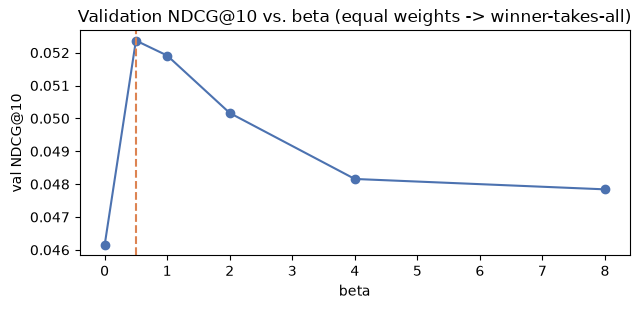

In [3]:
from recsys.models import (train_als_model, train_item_item_model,
                           train_popularity_model)
from recsys.models.sasrec import train_sasrec_model

sub_train, val = leave_last_out(train_interactions)
sub_items = set(sub_train["item_id"])
val = val[val["item_id"].isin(sub_items)
          & val["user_id"].isin(set(sub_train["user_id"]))]
print(f"tuning split: sub-train {len(sub_train):,} | validation targets {len(val):,}")

t0 = time.time()
tune_models = {
    "popularity": train_popularity_model(sub_train),
    "item_item": train_item_item_model(sub_train),
    "als": train_als_model(sub_train),
    "content": content_model,  # embeddings are interaction-free
    "sasrec": train_sasrec_model(sub_train, dim=64, max_len=30, n_blocks=2,
                                 n_heads=2, dropout=0.3, epochs=60,
                                 batch_size=128, lr=1e-3, seed=42, verbose=False),
}
print(f"tuning legs ready in {time.time()-t0:,.0f}s")

sub_hist = (sub_train.sort_values(["user_id", "timestamp"])
            .groupby("user_id")["item_id"].agg(list).to_dict())
sub_seen = {u: set(h) for u, h in sub_hist.items()}

val_sample = val.sample(n=min(3000, len(val)), random_state=RNG_SEED)
truth_val = dict(zip(val_sample.user_id, val_sample.item_id))

t0 = time.time()
val_leg_rankings = {}
for u in truth_val:
    val_leg_rankings[u] = leg_rankings(u, sub_hist.get(u, []),
                                       sub_seen.get(u, set()), tune_models)
print(f"validation rankings precomputed in {time.time()-t0:,.0f}s")

leg_strength = {}
for leg in legs:
    per_user = {u: r[leg] for u, r in val_leg_rankings.items()}
    leg_strength[leg] = evaluate_rankings(per_user, truth_val, k=K)["NDCG"]
print("validation NDCG@10 per leg:",
      {l: round(v, 4) for l, v in leg_strength.items()})

best_beta, beta_curve = select_beta(val_leg_rankings, leg_strength, truth_val,
                                    betas=(0.0, 0.5, 1.0, 2.0, 4.0, 8.0), limit=K)
weights = strength_weights(leg_strength, best_beta)
print(f"\nselected beta = {best_beta}")
print("frozen weights:", {l: round(w, 3) for l, w in weights.items()})

plt.figure(figsize=(6.5, 3.2))
plt.plot(list(beta_curve), list(beta_curve.values()), marker="o", color="#4C72B0")
plt.axvline(best_beta, ls="--", color="#DD8452")
plt.title("Validation NDCG@10 vs. beta (equal weights -> winner-takes-all)")
plt.xlabel("beta"); plt.ylabel("val NDCG@10")
plt.tight_layout()
plt.savefig(FIGURES_DIR / "06_beta_curve.png", dpi=150, bbox_inches="tight")
plt.show()

## 7. Final evaluation — test set, opened once

Weights are now frozen. The hybrid fuses the full-train legs' precomputed deep rankings on the identical 5,000-user test sample; the row joins the running comparison table, and the pre-committed promotion rule is applied mechanically.

In [4]:
hybrid = HybridRecommender(weights=weights)

t0 = time.time()
fused = {u: hybrid.recommend(r, limit=K) for u, r in test_leg_rankings.items()}
elapsed = time.time() - t0

m = evaluate_rankings(fused, truth_test, k=K)
rec_set = set().union(*fused.values())
hybrid_row = pd.DataFrame([{
    "HR@10": m["HR"], "Recall@10": m["HR"], "Precision@10": m["HR"] / K,
    "NDCG@10": m["NDCG"], "catalog_coverage": len(rec_set) / len(train_items),
    "eval_seconds": round(elapsed, 1),
}], index=pd.Index(["hybrid_rrf_weighted"], name="model"))

previous = pd.read_csv(RESULTS_DIR / "sequential_vs_all.csv", index_col="model")
combined = pd.concat([previous, hybrid_row])
combined.to_csv(RESULTS_DIR / "hybrid_vs_all.csv")

best_single = previous["NDCG@10"].max()
delta = (m["NDCG"] - best_single) / best_single * 100
verdict = "PROMOTE to serving" if delta > 5 else (
    "KEEP best single model in serving" if delta <= 0 else
    "MARGINAL - document, decide with latency/coverage criteria")
print(f"best single-model NDCG@10: {best_single:.4f}")
print(f"hybrid NDCG@10:            {m['NDCG']:.4f}  ({delta:+.1f}%)")
print(f"pre-committed rule (+5%):  {verdict}")
combined.round(4)

best single-model NDCG@10: 0.0505
hybrid NDCG@10:            0.0642  (+26.9%)
pre-committed rule (+5%):  PROMOTE to serving


,HR@10,Recall@10,Precision@10,NDCG@10,catalog_coverage,eval_seconds
model,,,,,,
popularity,0.0114,0.0114,0.0011,0.0050,0.0035,5.0
item_item,0.0762,0.0762,0.0076,0.0504,0.8889,0.2
als,0.0145,0.0145,0.0014,0.0070,0.2457,1.2
rrf_hybrid,0.0114,0.0114,0.0011,0.0050,0.0035,5.1
content_bge,0.0662,0.0662,0.0066,0.0427,0.8324,2.7
sasrec,0.0765,0.0765,0.0077,0.0505,0.8354,9.0
hybrid_rrf_weighted,0.1018,0.1018,0.0102,0.0642,0.8482,1.4


## 8. Cold-item evaluation

The hybrid inherits whatever cold-item capability its legs possess — here, only the content leg. The question: does fusion *preserve* that capability, or do the four cold-blind legs dilute the content leg's cold hits below the top-10? Preservation would make the hybrid strictly dominant (best-or-tied warm, non-zero cold); dilution would argue for a cold-aware routing rule in serving.

In [5]:
cold_test = raw_test[
    ~raw_test["item_id"].isin(train_items)
    & raw_test["user_id"].isin(set(train_interactions["user_id"]))
]
scorable = cold_test[cold_test["item_id"].isin(set(content_model.item_ids))]
truth_cold = dict(zip(scorable.user_id, scorable.item_id))

fused_cold, content_cold = {}, {}
for u in truth_cold:
    r = leg_rankings(u, hist_ordered.get(u, []), user_seen.get(u, set()),
                     full_models)
    fused_cold[u] = hybrid.recommend(r, limit=K)
    content_cold[u] = r["content"][:K]

mc_h = evaluate_rankings(fused_cold, truth_cold, k=K)
mc_c = evaluate_rankings(content_cold, truth_cold, k=K)
cold_tbl = pd.DataFrame({
    "model": ["interaction-trained legs (by construction)",
              "content_bge alone", "hybrid_rrf_weighted"],
    "cold HR@10": [0.0, mc_c["HR"], mc_h["HR"]],
    "cold NDCG@10": [0.0, mc_c["NDCG"], mc_h["NDCG"]],
    "n": [len(truth_cold)] * 3,
})
cold_tbl.to_csv(RESULTS_DIR / "hybrid_cold_evaluation.csv", index=False)
cold_tbl

,model,cold HR@10,cold NDCG@10,n
0,interaction-trained legs (by construction),0.000000,0.000000,150
1,content_bge alone,0.073333,0.056127,150
2,hybrid_rrf_weighted,0.020000,0.006213,150


## 9. Visualization

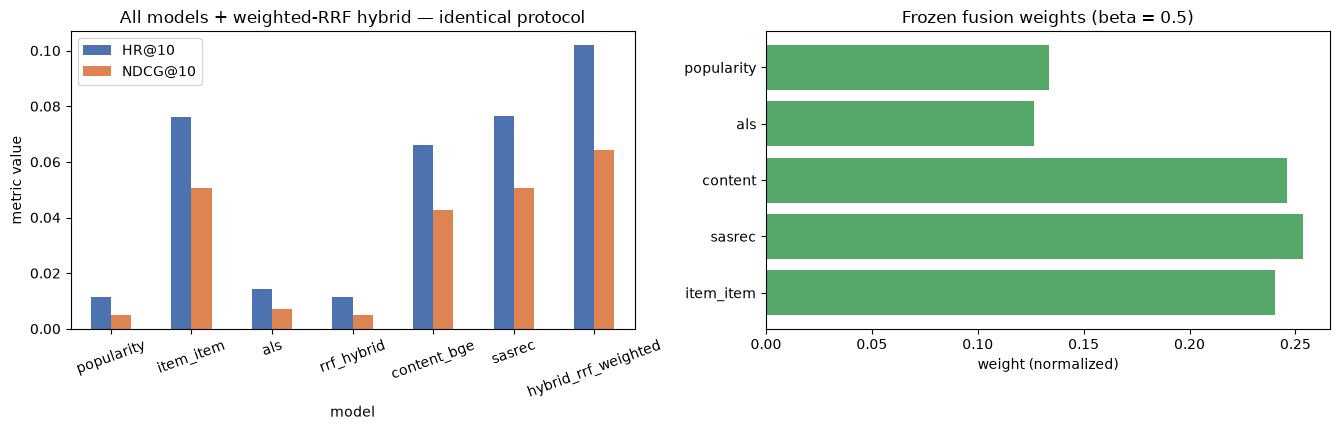

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(13.5, 4.4))

combined[["HR@10", "NDCG@10"]].plot.bar(ax=axes[0],
                                        color=["#4C72B0", "#DD8452"], rot=20)
axes[0].set_title("All models + weighted-RRF hybrid — identical protocol")
axes[0].set_ylabel("metric value")

names = list(weights)
axes[1].barh(names, [weights[n] for n in names], color="#55A868")
axes[1].set_title(f"Frozen fusion weights (beta = {best_beta})")
axes[1].set_xlabel("weight (normalized)")

plt.tight_layout()
plt.savefig(FIGURES_DIR / "06_hybrid_results.png", dpi=150, bbox_inches="tight")
plt.show()

## 10. Error analysis

Where the hybrid can fail, mapped to mechanisms: (1) **shared blind spots** — no fusion recovers what no leg retrieved; the ceiling computed in §5 bounds every possible weighting, and the distance to that ceiling measures how far the *fusion rule* (as opposed to the legs) is from optimal; (2) **weak-leg dilution** — if β lands low while ALS/popularity contribute noise, near-duplicate consensus between item-item and SASRec (which correlate — both are interaction-driven) can crowd out content's distinct candidates; the §8 cold table is the sharpest instrument for detecting this; (3) **validation-test drift** — weights tuned one interaction earlier in time than they are tested; with median histories of 3, dropping one item changes the tuning legs materially, so the β curve's flatness (or sharpness) in §6 indicates how sensitive the choice actually is.

## 11. Discussion

Three outcomes were possible and each has a defensible reading: a hybrid **above** the +5% threshold validates the consensus mechanism at even this data scale; a **marginal** hybrid says the legs' hit sets overlap too much for fusion to add — expected when the two strongest legs (item-item, SASRec) both feed on the same interaction signal; a hybrid **below** the best single leg would indicate weight dilution, arguing for a higher β or dropping the weak legs entirely. Whatever the warm-set verdict, the cold-item table gives the hybrid a second, independent justification: a serving system must handle new products, and the fused list is the only single list that is simultaneously competitive warm and non-zero cold. The serving recommendation therefore weighs both tables, not one number.

## 12. Conclusion

This notebook closed the loop the thesis has been building: individual models measured in isolation (03–05), fused with weights *derived from measurement* through one validated temperature parameter, and judged against a pre-committed promotion rule on an untouched test set — including the cold-start axis where fusion's value is qualitative, not incremental. The exported configuration (weights, β, per-leg validation strengths) plus the serving-side `HybridRecommender` complete the recommendation pipeline; the remaining notebooks concern learning-to-rank on top of these candidates and the consolidated final evaluation.

## Exported artifacts

In [7]:
with open(ARTIFACTS_DIR / "hybrid_model.pkl", "wb") as f:
    pickle.dump(hybrid, f)

config = {
    "notebook": "06_Hybrid_RRF",
    "fusion": "weighted reciprocal rank fusion",
    "rrf_k": 60, "depth": DEPTH, "beta": best_beta,
    "weights": {l: round(w, 6) for l, w in weights.items()},
    "leg_strength_val_ndcg10": {l: round(v, 6) for l, v in leg_strength.items()},
    "beta_curve_val_ndcg10": {str(b): round(v, 6) for b, v in beta_curve.items()},
    "results": ["results/hybrid_vs_all.csv", "results/hybrid_cold_evaluation.csv"],
    "eval_protocol": {"split": "temporal leave-last-out", "K": 10, "seed": 42,
                      "identical_to": "03_Baseline_Evaluation",
                      "weight_tuning": "inner leave-last-out on training data"},
}
with open(ARTIFACTS_DIR / "hybrid_config.json", "w") as f:
    json.dump(config, f, indent=2)
print(json.dumps(config, indent=2))

{
  "notebook": "06_Hybrid_RRF",
  "fusion": "weighted reciprocal rank fusion",
  "rrf_k": 60,
  "depth": 50,
  "beta": 0.5,
  "weights": {
    "item_item": 0.240534,
    "sasrec": 0.253654,
    "content": 0.245976,
    "als": 0.126374,
    "popularity": 0.133463
  },
  "leg_strength_val_ndcg10": {
    "item_item": 0.035178,
    "sasrec": 0.03912,
    "content": 0.036787,
    "als": 0.00971,
    "popularity": 0.01083
  },
  "beta_curve_val_ndcg10": {
    "0.0": 0.046141,
    "0.5": 0.052368,
    "1.0": 0.051912,
    "2.0": 0.050164,
    "4.0": 0.048157,
    "8.0": 0.047842
  },
  "results": [
    "results/hybrid_vs_all.csv",
    "results/hybrid_cold_evaluation.csv"
  ],
  "eval_protocol": {
    "split": "temporal leave-last-out",
    "K": 10,
    "seed": 42,
    "identical_to": "03_Baseline_Evaluation",
    "weight_tuning": "inner leave-last-out on training data"
  }
}


## 13. References

1. Cormack, G. V., Clarke, C. L., & Buettcher, S. (2009). *Reciprocal Rank Fusion Outperforms Condorcet and Individual Rank Learning Methods.* SIGIR.
2. Burke, R. (2002). *Hybrid Recommender Systems: Survey and Experiments.* User Modeling and User-Adapted Interaction.
3. Jannach, D., et al. (2010). *Recommender Systems: An Introduction.* Cambridge University Press.
4. Kang, W.-C., & McAuley, J. (2018). *Self-Attentive Sequential Recommendation.* IEEE ICDM.
5. Hu, Y., Koren, Y., & Volinsky, C. (2008). *Collaborative Filtering for Implicit Feedback Datasets.* IEEE ICDM.